# DESAFIO 5

## DETECÇÃO DE FRAUDES EM TRANSAÇÕES FINANCEIRAS

In [1]:
import pandas as pd

url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"

df = pd.read_csv(url)

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


# Problema de Classificação desbalanceada

Fraudes são raras --> modelo para ignorar a classe 1.

In [2]:
df["Class"].value_counts(normalize=True)

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

In [3]:
# Entendo os valores acima: 99,83% de transações normais e 0,17% são anomalias (fraudes)

# Featuring Engineering

Criamos variáveis eu ajudam o modelo.

In [4]:
import numpy as np

df["Amount_log"] = np.log1p(df["Amount"])

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df["Amount_scaled"] = scaler.fit_transform(df[["Amount"]])

In [6]:
from sklearn.model_selection import train_test_split

X = df.drop("Class", axis=1)
y = df["Class"]

# 30% dos dados para teste e 70% para treino do modelo

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.3, random_state=42
)

# Logistic Regression

In [7]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [8]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.84      0.63      0.72       148

    accuracy                           1.00     85443
   macro avg       0.92      0.81      0.86     85443
weighted avg       1.00      1.00      1.00     85443



Accuracy pode ser alta mesmo sem dectar fraude.

Por isso usamos:

- Recall (mais importante)
- Precision
- F1-score

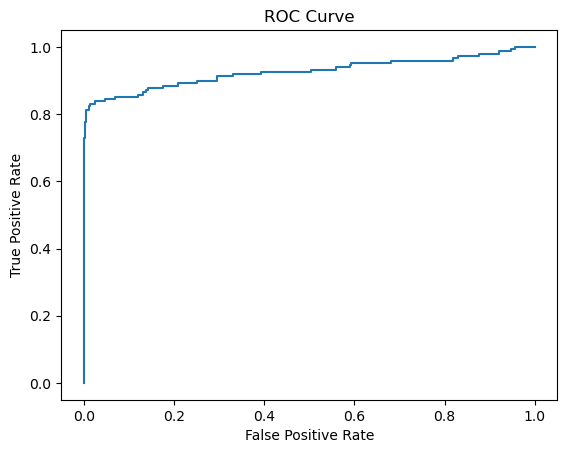

AUC: 0.925859615990925


In [9]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_probs = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_probs)

plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

print("AUC:", roc_auc_score(y_test, y_probs))

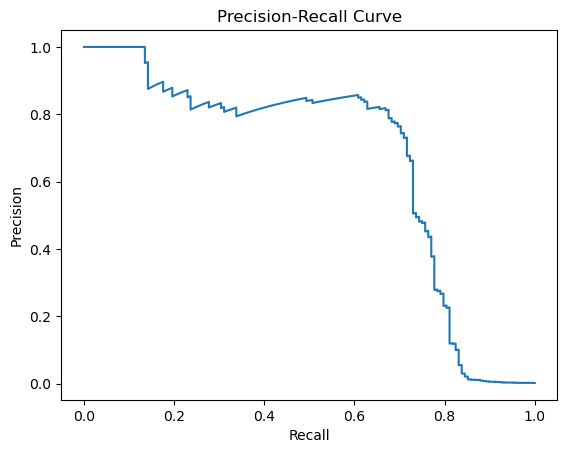

In [10]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_probs)

plt.plot(recall, precision)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()


# Balenceamento de Dados

In [11]:
# Undersampling
fraudes = df[df['Class'] == 1]
normais = df[df['Class'] == 0].sample(len(fraudes), random_state=42)

df_under = pd.concat([fraudes, normais])

In [12]:
# Oversampling
from imblearn.over_sampling import SMOTE

smote = SMOTE()

X_res, y_res = smote.fit_resample(X, y)

In [13]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=50,
)

In [14]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.84      0.76      0.79       148

    accuracy                           1.00     85443
   macro avg       0.92      0.88      0.90     85443
weighted avg       1.00      1.00      1.00     85443



In [15]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

In [17]:
threshold = 0.3
y_pred_custom = (y_probs > threshold).astype(int)

print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.80      0.68      0.73       148

    accuracy                           1.00     85443
   macro avg       0.90      0.84      0.87     85443
weighted avg       1.00      1.00      1.00     85443



# Modelo Avançado - XGBoost

XGBoost é um dos algoritmos mais utilizado em competições e mercado.

Ele é mais poderoso que o Random Forest para muitos problemas.

In [20]:
%pip install xgboost

   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.1/48.9 MB 2.4 MB/s eta 0:00:21
   ---------------------------------------- 0.3/48.9 MB 3.3 MB/s eta 0:00:15
   ---------------------------------------- 0.5/48.9 MB 3.9 MB/s eta 0:00:13
    --------------------------------------- 0.7/48.9 MB 3.8 MB/s eta 0:00:13
    --------------------------------------- 0.9/48.9 MB 3.9 MB/s eta 0:00:13
    --------------------------------------- 1.2/48.9 MB 4.1 MB/s eta 0:00:12
   - -------------------------------------- 1.3/48.9 MB 3.9 MB/s eta 0:00:13
   - -------------------------------------- 1.5/48.9 MB 3.9 MB/s eta 0:00:13
   - -------------------------------------- 1.6/48.9 MB 3.8 MB/s eta 0:00:13
   - -------------------------------------- 1.8/48.9 MB 3.9 MB/s eta 0:00:13
   - -------------------------------------- 2.1/48.9 MB 4.0 MB/s eta 0:00:12
   - -------------------------------------- 2.2/48.9 MB 3.9 MB/s eta 0:00:13
   - -

In [21]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    scale_pos_weight=10,  # ajuda com desbalanceamento
    use_label_encoder=False,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

C:\Users\Dell\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [08:07:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [22]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.94      0.78      0.85       148

    accuracy                           1.00     85443
   macro avg       0.97      0.89      0.93     85443
weighted avg       1.00      1.00      1.00     85443



# Importância das Variáveis

Ajuda a entender quais variáveis influenciam mais o modelo

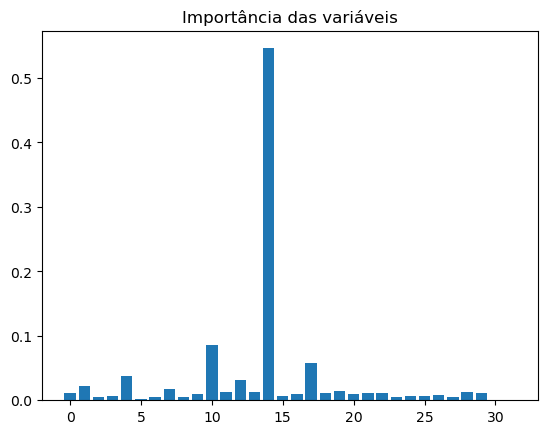

In [23]:
import matplotlib.pyplot as plt

importancias = xgb.feature_importances_

plt.bar(range(len(importancias)), importancias)
plt.title("Importância das variáveis")
plt.show()

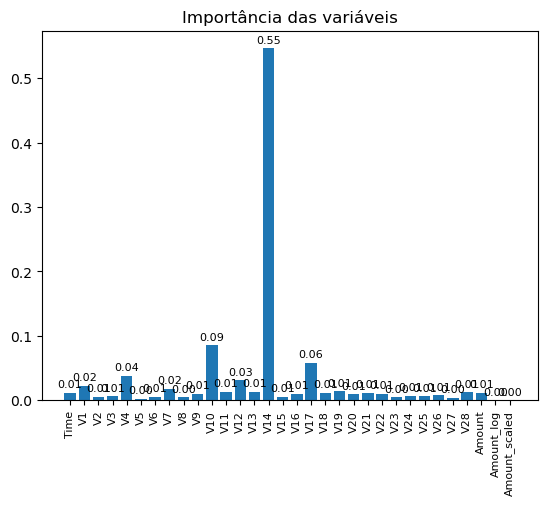

In [40]:
# Identificando a variável que mais influenciou no modelo

importancias = xgb.feature_importances_

feature_names = X_train.columns  # se X_train for um DataFrame do pandas

# Gráfico de barras
plt.bar(range(len(importancias)), importancias)
plt.title("Importância das variáveis")

# Adiciona rótulos acima de cada barra
for i, v in enumerate(importancias):
    plt.text(i, v + 0.005, f"{v:.2f}", ha="center", fontsize=8, va="bottom")

# Rótulos do eixo X na vertical e com fonte menor
plt.xticks(range(len(importancias)), feature_names, rotation=90, fontsize=8)

plt.show()

# Ajuste de Hiperparâmetros

Testamos várias combinações para melhorar o modelo.

In [30]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth": [3, 5],
    "n_estimators": [50, 100]
}

grid = GridSearchCV(
    XGBClassifier(eval_metric="logloss"),
    param_grid,
    scoring="recall",
    cv=3
)

grid.fit(X_train, y_train)

# Exibe os melhores parâmetros encontrados
print("Melhor modelo:", grid.best_params_)

Melhor modelo: {'max_depth': 5, 'n_estimators': 100}


# Explicabilidade (SHAP)

SHAP mostra como cada variável influencia a decisão do modelo.

In [32]:
%pip install shap

     ---------------------------------------- 0.0/60.8 kB ? eta -:--:--
     ---------------------------------------- 60.8/60.8 kB ? eta 0:00:00
   ---------------------------------------- 0.0/499.9 kB ? eta -:--:--
   -------- ------------------------------- 102.4/499.9 kB 3.0 MB/s eta 0:00:01
   ---------------- ----------------------- 204.8/499.9 kB 2.5 MB/s eta 0:00:01
   --------------------------- ------------ 337.9/499.9 kB 2.6 MB/s eta 0:00:01
   ---------------------------------- ----- 430.1/499.9 kB 2.4 MB/s eta 0:00:01
   ---------------------------------------- 499.9/499.9 kB 2.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   ---------------------------------------- 0.1/12.6 MB 4.2 MB/s eta 0:00:03
    --------------------------------------- 0.2/12.6 MB 2.7 MB/s eta 0:00:05
   - -------------------------------------- 0.4/12.6 MB 3.3 MB/s eta 0:00:04
   -- ------------------------------------- 0.6/12.6 MB 3.7 MB/s eta 0:00:04
   -- 

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.2.6 which is incompatible.
pywavelets 1.5.0 requires numpy<2.0,>=1.22.4, but you have numpy 2.2.6 which is incompatible.
tensorflow-intel 2.17.0 requires numpy<2.0.0,>=1.26.0; python_version >= "3.12", but you have numpy 2.2.6 which is incompatible.
tensorflow-intel 2.17.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<5.0.0dev,>=3.20.3, but you have protobuf 5.29.3 which is incompatible.


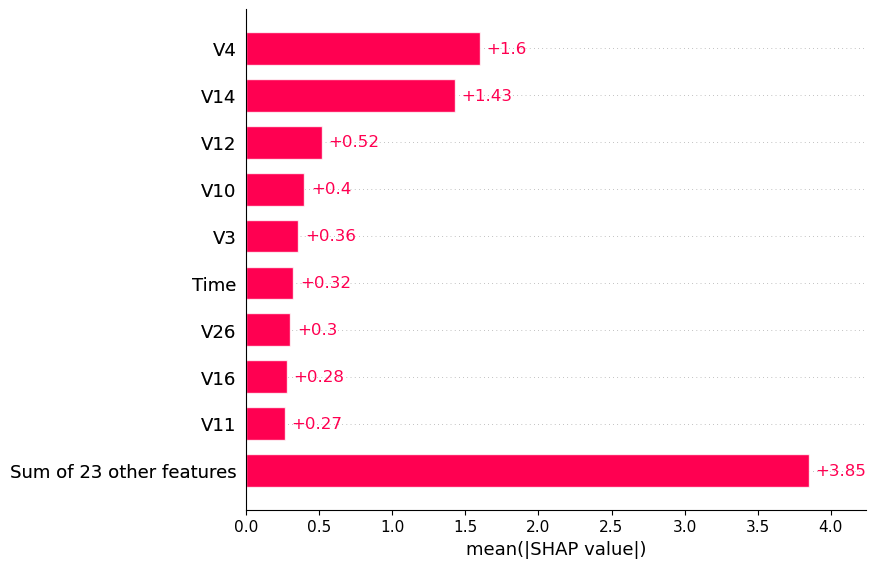

In [33]:
import shap

explainer = shap.Explainer(xgb)

shap_values = explainer(X_test[:100])

shap.plots.bar(shap_values)